# Multimodal Fusion Workshop — Rice Yield Prediction

Dataset link : https://drive.google.com/drive/folders/1l01dyB_xdaX9YtCOAXz7AwEnWg3o_c79?usp=drive_link

A small, readable model that predicts rice yield by fusing three data
sources with cross-attention:

| Modality | File | Nature |
|---|---|---|
| Satellite (Sentinel-2) | `sentinel2_rice_histogram_India_2016-2023_64bin.npz` | sequence over the growing season |
| Soil | `soil_india_new/soil_india_new/soil_histogram_india_<district>.npz` | static, one vector per district |
| Weather | `soil_india_new/met_india_sentinel_2016_2025.csv` | sequence over the growing season |
| Yield (target) | `ricegroundtruth-2014-23.csv` | one value per district-year |

**What this notebook shows:**
1. Loading and aligning three real, differently-shaped data sources.
2. Encoding each modality into a shared embedding space.
3. Fusing them with **cross-attention** — one modality's sequence "asks
   questions" of the other two.
4. Training a tiny model and visualizing what the attention actually
   learned to focus on.

>  Paths and column/key names below assume the same Google Drive layout
> as the source dataset. If a load step's printed shape/columns look off,
> check the cell marked `# CHECK` right above it.

## 1. Imports & Drive mount

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Mounted at /content/drive
Using device: cpu


## 2. Paths

In [ ]:
BASE = '/content/drive/MyDrive/EYNet-Model/EYNet'

SENTINEL_PATH = f'{BASE}/sentinel2_rice_histogram_India_2016-2023_64bin.npz'
GROUND_TRUTH_PATH = f'{BASE}/ricegroundtruth-2014-23.csv'
SOIL_DIR = f'{BASE}/soil_india_new/soil_india_new'
MET_PATH = f'{BASE}/soil_india_new/met_india_sentinel_2016_2025.csv'

# Growing-season window (timesteps) used for both satellite and weather
TIMESTEPS = list(range(16, 31))

## 3. Load satellite data

`output_index` gives `[state_id, dist_id]` per sample, `output_year` gives
the year, `output_image` is the satellite sequence. We average over the
histogram-bin dimension so each sample becomes a plain `(time, channels)`
sequence — simple enough for a small encoder, still genuinely temporal.

In [ ]:
sentinel = np.load(SENTINEL_PATH)
print("Keys in Sentinel-2 file:", sentinel.files)  # CHECK

image_all = sentinel['output_image']       # (N, bins, time, channels)
year_all  = sentinel['output_year'].astype(int)
index_all = sentinel['output_index'].astype(int)   # (N, 2) -> [state_id, dist_id]

print("Raw satellite image shape:", image_all.shape)

T_avail = image_all.shape[2]
time_idx = np.array([t for t in TIMESTEPS if t < T_avail])

sat_seq_all = image_all[:, :, time_idx, :].mean(axis=1)   # (N, T, channels)
print("Satellite sequence per sample:", sat_seq_all.shape)

sat_index_df = pd.DataFrame({
    'state':  index_all[:, 0],
    'county': index_all[:, 1],
    'year':   year_all,
    'row_idx': np.arange(len(sat_seq_all)),
})
sat_index_df.head()

Keys in Sentinel-2 file: ['output_image', 'output_yield', 'output_year', 'output_locations', 'output_index']
Raw satellite image shape: (1992, 64, 37, 12)
Satellite sequence per sample: (1992, 15, 12)


,state,county,year,row_idx
0,2,3,2016,0
1,2,3,2017,1
2,2,3,2018,2
3,2,3,2019,3
4,2,3,2020,4


## 4. Load yield and align with satellite

In [ ]:
gt = pd.read_csv(GROUND_TRUTH_PATH)
print("Ground truth columns:", gt.columns.tolist())  # CHECK

gt = gt[['state_id', 'dist_id', 'year', 'YieldBuAc']].dropna()
gt.columns = ['state', 'county', 'year', 'yield']

aligned = sat_index_df.merge(gt, on=['state', 'county', 'year'], how='inner')
print("Satellite + yield matched rows:", len(aligned))
aligned.head()

Ground truth columns: ['state_id', 'state', 'dist_id', 'dist', 'year', 'yieldtonnehectare', 'YieldBuAc']
Satellite + yield matched rows: 1992


,state,county,year,row_idx,yield
0,2,3,2016,0,36.430647
1,2,3,2017,1,37.322827
2,2,3,2018,2,39.701971
3,2,3,2019,3,53.679444
4,2,3,2020,4,40.445454


## 5. Load soil data (static per district)

Soil has no time dimension, so it's merged only on `(state, county)` — one
soil vector describes a whole district, reused for every year of that
district.

In [ ]:
def load_soil_record(dist_id, soil_dir):
    path = os.path.join(soil_dir, f"soil_histogram_india_{dist_id}.npz")
    if not os.path.exists(path):
        return None
    d = np.load(path, allow_pickle=True)
    img = np.squeeze(d['output_image'])              # CHECK
    vec = img.reshape(img.shape[0], -1).mean(axis=0) if img.ndim > 1 else img
    state_val  = int(np.array(d['output_state']).reshape(-1)[0])
    county_val = int(np.array(d['output_county']).reshape(-1)[0])
    return {'state': state_val, 'county': county_val, 'soil_vec': vec.astype(np.float32)}


soil_records = []
for dist_id in aligned['county'].unique():
    rec = load_soil_record(int(dist_id), SOIL_DIR)
    if rec is not None:
        soil_records.append(rec)

soil_df = pd.DataFrame(soil_records)
print("Districts with soil data found:", len(soil_df))

aligned = aligned.merge(soil_df, on=['state', 'county'], how='inner')
print("After merging soil:", len(aligned))

Districts with soil data found: 249
After merging soil: 1992


## 6. Load weather data and build per-district-per-year sequences

Filter to the same growing-season timestamps as the satellite window,
normalize each feature to [0, 1], then reshape into one `(time, features)`
sequence per `(state, county, year)`.

In [ ]:
met = pd.read_csv(MET_PATH)

print("Weather columns:", met.columns.tolist())

met_features = [
    'tempmax', 'tempmin', 'dew', 'humidity', 'precip',
    'windspeed', 'sealevelpressure', 'cloudcover',
    'visibility', 'solarradiation', 'solarenergy'
]

met_features = [c for c in met_features if c in met.columns]

met = met[met['timestamp'].isin(TIMESTEPS)].copy()

# Fill missing values and normalize
for c in met_features:
    met[c] = met[c].ffill().bfill()

    lo, hi = met[c].min(), met[c].max()
    met[c] = (met[c] - lo) / (hi - lo + 1e-8)

# Group weather data
met_grouped = (
    met.groupby(['state', 'county', 'Year', 'timestamp'])[met_features]
       .mean()
       .reset_index()
)

def build_met_sequence(group):

    g = group.set_index('timestamp').reindex(TIMESTEPS)

    # Fill missing timestamps
    g[met_features] = (
        g[met_features]
        .ffill()
        .bfill()
        .fillna(0.0)
    )

    return g[met_features].values.astype(np.float32)


met_sequences = {
    key: build_met_sequence(group)
    for key, group in met_grouped.groupby(['state', 'county', 'Year'])
}

print(
    "Weather sequences built for",
    len(met_sequences),
    "(state, county, year) combos"
)

Weather columns: ['state', 'county', 'Year', 'timestamp', 'tempmax', 'tempmin', 'dew', 'humidity', 'precip', 'windspeed', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy']
Weather sequences built for 5075 (state, county, year) combos


## 7. Attach weather sequences and assemble final arrays

In [ ]:
def lookup_met(row):
    key = (row['state'], row['county'], row['year'])
    return met_sequences.get(key)

aligned['met_seq'] = aligned.apply(lookup_met, axis=1)
aligned = aligned[aligned['met_seq'].notna()].reset_index(drop=True)
print("Final rows with satellite + soil + weather + yield all matched:", len(aligned))

# Ensure 'soil_vec' column is present, re-merging if necessary due to unexpected state
if 'soil_vec' not in aligned.columns:
    print("Warning: 'soil_vec' column not found. Re-merging soil data to ensure its presence.")
    # Assuming soil_df is available from a previous cell and contains 'state', 'county', 'soil_vec'
    aligned = aligned.merge(soil_df[['state', 'county', 'soil_vec']], on=['state', 'county'], how='left')

X_sat  = sat_seq_all[aligned['row_idx'].values]                       # (N, T, C_sat)
X_soil = np.stack(aligned['soil_vec'].values)                          # (N, C_soil)
X_met  = np.stack(aligned['met_seq'].values)                           # (N, T, C_met)
y      = aligned['yield'].values.astype(np.float32)                    # (N,)
years  = aligned['year'].values.astype(int)

print("X_sat :", X_sat.shape)
print("X_soil:", X_soil.shape)
print("X_met :", X_met.shape)
print("y     :", y.shape)

Final rows with satellite + soil + weather + yield all matched: 1989
X_sat : (1989, 15, 12)
X_soil: (1989, 36)
X_met : (1989, 15, 11)
y     : (1989,)


## 8. Train / validation / test split by year

In [ ]:
START_YEAR = int(years.min())
VAL_YEAR   = int(years.max()) - 1
TEST_YEAR  = int(years.max())
print(f"train: {START_YEAR}-{VAL_YEAR - 1} | val: {VAL_YEAR} | test: {TEST_YEAR}")

train_mask = (years >= START_YEAR) & (years < VAL_YEAR)
val_mask   = years == VAL_YEAR
test_mask  = years == TEST_YEAR

print("train/val/test sizes:", train_mask.sum(), val_mask.sum(), test_mask.sum())

train: 2016-2021 | val: 2022 | test: 2023
train/val/test sizes: 1493 248 248


## 9. Dataset / DataLoader

In [ ]:
class RiceDataset(Dataset):
    def __init__(self, satellite, soil, weather, yields):
        self.satellite = torch.tensor(satellite)
        self.soil      = torch.tensor(soil)
        self.weather   = torch.tensor(weather)
        self.yields    = torch.tensor(yields)

    def __len__(self):
        return len(self.yields)

    def __getitem__(self, idx):
        return self.satellite[idx], self.soil[idx], self.weather[idx], self.yields[idx]


def subset(mask):
    return X_sat[mask], X_soil[mask], X_met[mask], y[mask]

train_loader = DataLoader(RiceDataset(*subset(train_mask)), batch_size=16, shuffle=True)
val_loader   = DataLoader(RiceDataset(*subset(val_mask)),   batch_size=16, shuffle=False)
test_loader  = DataLoader(RiceDataset(*subset(test_mask)),  batch_size=16, shuffle=False)

## 10. Encoders — one small encoder per modality

Every modality gets projected into the same embedding size (`EMB_DIM`),
regardless of how different the raw feature counts are — that's what makes
fusion possible.

In [ ]:
EMB_DIM = 16
SAT_DIM  = X_sat.shape[-1]
MET_DIM  = X_met.shape[-1]
SOIL_DIM = X_soil.shape[-1]
print("SAT_DIM:", SAT_DIM, " MET_DIM:", MET_DIM, " SOIL_DIM:", SOIL_DIM)


class SequenceEncoder(nn.Module):
    """(B, T, F) -> (B, T, EMB_DIM), for satellite or weather sequences."""
    def __init__(self, in_dim, emb_dim=EMB_DIM):
        super().__init__()
        self.proj = nn.Linear(in_dim, emb_dim)

    def forward(self, x):
        return F.relu(self.proj(x))


class StaticEncoder(nn.Module):
    """(B, F) -> (B, 1, EMB_DIM), soil becomes a single 'token'."""
    def __init__(self, in_dim, emb_dim=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, emb_dim), nn.ReLU(), nn.Linear(emb_dim, emb_dim)
        )

    def forward(self, x):
        return self.net(x).unsqueeze(1)

SAT_DIM: 12  MET_DIM: 11  SOIL_DIM: 36


## 11. Cross-attention fusion

Each **satellite timestep** (query) attends over **all weather timesteps +
the soil token** (key/value): *"which of your timesteps/tokens matter for me
right now?"* `nn.MultiheadAttention` also returns the attention weights,
which we'll visualize later.

In [ ]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, num_heads=2):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(emb_dim)

    def forward(self, query, key_value):
        attn_out, attn_weights = self.attn(query, key_value, key_value)
        fused = self.norm(query + attn_out)   # residual connection
        return fused, attn_weights


class SimpleMultimodalYieldModel(nn.Module):
    def __init__(self, sat_dim=SAT_DIM, met_dim=MET_DIM, soil_dim=SOIL_DIM, emb_dim=EMB_DIM):
        super().__init__()
        self.sat_encoder  = SequenceEncoder(sat_dim, emb_dim)
        self.met_encoder  = SequenceEncoder(met_dim, emb_dim)
        self.soil_encoder = StaticEncoder(soil_dim, emb_dim)
        self.fusion = CrossAttentionFusion(emb_dim)
        self.head = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.ReLU(), nn.Linear(emb_dim, 1))

    def forward(self, satellite, soil, weather):
        sat_emb  = self.sat_encoder(satellite)             # (B, T, D)
        met_emb  = self.met_encoder(weather)                # (B, T, D)
        soil_emb = self.soil_encoder(soil)                    # (B, 1, D)

        context = torch.cat([met_emb, soil_emb], dim=1)       # (B, T+1, D)
        fused, attn_weights = self.fusion(sat_emb, context)     # (B, T, D)

        pooled = fused.mean(dim=1)                               # (B, D)
        yield_pred = self.head(pooled).squeeze(-1)                # (B,)
        return yield_pred, attn_weights


model = SimpleMultimodalYieldModel().to(device)
print(model)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

SimpleMultimodalYieldModel(
  (sat_encoder): SequenceEncoder(
    (proj): Linear(in_features=12, out_features=16, bias=True)
  )
  (met_encoder): SequenceEncoder(
    (proj): Linear(in_features=11, out_features=16, bias=True)
  )
  (soil_encoder): StaticEncoder(
    (net): Sequential(
      (0): Linear(in_features=36, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
    )
  )
  (fusion): CrossAttentionFusion(
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
    )
    (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (head): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)
Total parameters: 2673


## 12. Train

In [ ]:
import math

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 40
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):

    # =========================
    # Training
    # =========================
    model.train()
    running, n = 0.0, 0

    for sat, soil, wea, yt in train_loader:

        sat = sat.float().to(device)
        soil = soil.float().to(device)
        wea = wea.float().to(device)
        yt = yt.float().to(device)

        optimizer.zero_grad()

        pred, _ = model(sat, soil, wea)

        loss = criterion(pred, yt)

        loss.backward()
        optimizer.step()

        running += loss.item() * yt.size(0)
        n += yt.size(0)

    train_mse = running / max(n, 1)
    train_rmse = math.sqrt(train_mse)

    train_losses.append(train_rmse)

    # =========================
    # Validation
    # =========================
    model.eval()
    running, n = 0.0, 0

    with torch.no_grad():

        for sat, soil, wea, yt in val_loader:

            sat = sat.float().to(device)
            soil = soil.float().to(device)
            wea = wea.float().to(device)
            yt = yt.float().to(device)

            pred, _ = model(sat, soil, wea)

            loss = criterion(pred, yt)

            running += loss.item() * yt.size(0)
            n += yt.size(0)

    val_mse = running / max(n, 1)
    val_rmse = math.sqrt(val_mse)

    val_losses.append(val_rmse)

    # =========================
    # Print RMSE
    # =========================
    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d} | "
            f"train RMSE {train_rmse:8.2f} | "
            f"val RMSE {val_rmse:8.2f}"
        )

Epoch   1 | train RMSE    13.71 | val RMSE    14.31
Epoch   5 | train RMSE    13.71 | val RMSE    14.11
Epoch  10 | train RMSE    13.72 | val RMSE    14.25
Epoch  15 | train RMSE    13.69 | val RMSE    14.00
Epoch  20 | train RMSE    13.69 | val RMSE    14.44
Epoch  25 | train RMSE    13.69 | val RMSE    13.94
Epoch  30 | train RMSE    13.68 | val RMSE    14.01
Epoch  35 | train RMSE    13.67 | val RMSE    15.11
Epoch  40 | train RMSE    13.68 | val RMSE    14.54


Experiment 1 — change the number of epochs
Now make a small change only for your experiment:

Try training for 50 epochs instead of 40.

You can copy the training cell into a new cell, change EPOCHS, and run the copy. Keep the original cell unchanged so you can compare the two runs.

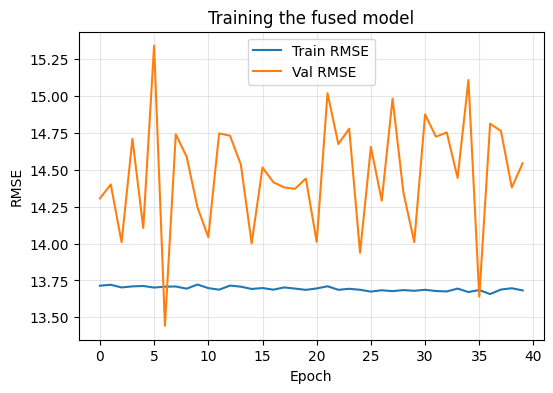

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(train_losses, label="Train RMSE")
plt.plot(val_losses, label="Val RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training the fused model")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13. Test-set RMSE

In [ ]:
model.eval()
sq_err, n = 0.0, 0
with torch.no_grad():
    for sat, soil, wea, yt in test_loader:
        sat, soil, wea, yt = sat.float().to(device), soil.float().to(device), wea.float().to(device), yt.float().to(device)
        pred, _ = model(sat, soil, wea)
        sq_err += ((pred - yt) ** 2).sum().item()
        n += yt.size(0)

rmse = (sq_err / max(n, 1)) ** 0.5
print(f"Test RMSE: {rmse:.2f}  (on {n} test samples)")

Test RMSE: 13.09  (on 248 test samples)


## 14. Visualize the attention

Rows = satellite timesteps (the "questions"), columns = weather timesteps +
the soil token (the "answers"). Brighter cells mean the satellite timestep
is relying more on that piece of weather/soil information.

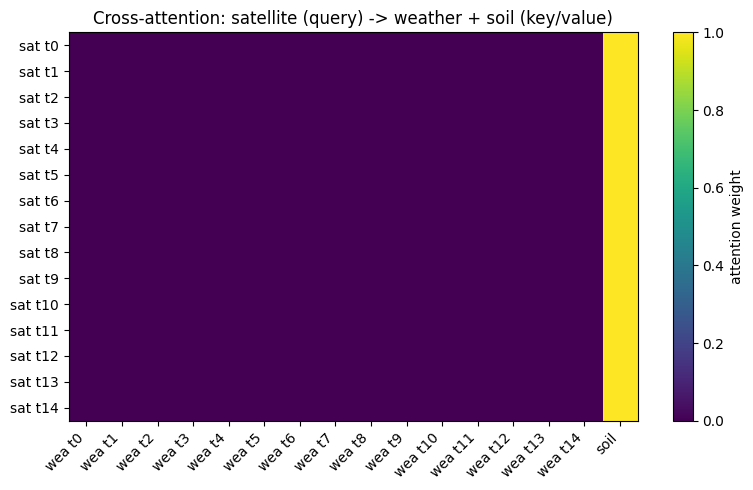

In [ ]:
sample_sat, sample_soil, sample_wea, sample_y = next(iter(test_loader))
sample_sat, sample_soil, sample_wea = sample_sat[:1].float().to(device), sample_soil[:1].float().to(device), sample_wea[:1].float().to(device)

model.eval()
with torch.no_grad():
    _, attn_weights = model(sample_sat, sample_soil, sample_wea)

weights = attn_weights[0].cpu().numpy()
T = X_sat.shape[1]
col_labels = [f"wea t{t}" for t in range(weights.shape[1] - 1)] + ["soil"]
row_labels = [f"sat t{t}" for t in range(T)]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(weights, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=45, ha="right")
ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
ax.set_title("Cross-attention: satellite (query) -> weather + soil (key/value)")
fig.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout(); plt.show()